In [6]:
import os.path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
from collections import defaultdict
import re

In [7]:
file_name = '2026-01-21_6_latency.csv'

all_data = []


df = pd.read_csv(os.path.join('./result/metrics/',file_name))
provModels = df['provModel'].unique().tolist()
datasets = df['dataset'].unique().tolist()

# provModels = df['provModel'].unique().tolist()
# datasets = df['dataset'].unique().tolist()

for provModel in provModels:
    all_data = {
    }
    for dataset in datasets:
        scale_factors = [0.1]
        # scale_factors = df['scaleFactor'].unique().tolist()
        sf_data=[]
        for sf in scale_factors:
            dt_sf_prov = df[ (df['provModel']== provModel) & (df['dataset'] == dataset) & (df['scaleFactor'] == sf)][['query','mean']]

            orig = dt_sf_prov[dt_sf_prov['query'].str.startswith('orig_')].set_index('query')
            prov = dt_sf_prov[dt_sf_prov['query'].str.startswith('prov_')].set_index('query')

            orig.index = orig.index.str.replace('orig_', '')
            prov.index = prov.index.str.replace('prov_', '')

            comparison = orig.join(prov, lsuffix='_orig', rsuffix='_prov')
            sf_data.append((sf,comparison))
        all_data[dataset]=sf_data

    fig, ax = plt.subplots(figsize=(14, 6))

    bar_width = 0.35
    gap_queries = 0.2
    gap_sf = 1.0
    gap_dataset = 2.0

    x_positions = []
    query_labels = []

    current_x = 0

    sf_centers = []
    dataset_centers = []

    for dataset_name, sf_list in all_data.items():
        dataset_start = current_x

        for sf_idx, (sf, comparison) in enumerate(sf_list):
            n_queries = len(comparison)
            x_inner = np.arange(current_x, current_x + n_queries)

            # Store query ticks
            x_positions.extend(x_inner)
            query_labels.extend(comparison.index)

            # Plot bars
            ax.bar(x_inner - bar_width / 2, comparison['mean_orig'],
                   width=bar_width,
                   label='orig' if current_x == 0 else "")
            ax.bar(x_inner + bar_width / 2, comparison['mean_prov'],
                   width=bar_width,
                   label='prov' if current_x == 0 else "")

            # Scale factor center
            sf_centers.append((x_inner.mean(), sf))

            current_x += n_queries + gap_sf

        dataset_end = current_x - gap_sf
        dataset_centers.append(((dataset_start + dataset_end) / 2, dataset_name))
        current_x += gap_dataset

    # ---- Query ticks (level 1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(query_labels, rotation=45, ha='right')

    ax.set_ylabel('Mean Value')
    ax.set_title(f"{provModel} Provenance : Original vs Provenance Query Latencies")

    # ---- Scale factor labels (level 2)
    ymin, ymax = ax.get_ylim()
    sf_y = ymin - (ymax - ymin) * 0.08

    for x, sf in sf_centers:
        ax.text(x, sf_y, f'SF {sf}', ha='center', va='top', fontsize=10)

    # ---- Dataset labels (level 3)
    dataset_y = ymin - (ymax - ymin) * 0.15

    for x, name in dataset_centers:
        ax.text(x, dataset_y, name, ha='center', va='top',
                fontsize=11, fontweight='bold')

    # ---- Layout
    plt.subplots_adjust(bottom=0.30)
    ax.legend()
    plt.show()




AttributeError: Can only use .str accessor with string values!

In [8]:

file_name = '2026-01-21_1_latency.csv'

def query_number(qid):
    """
    Extract numeric suffix from query id, e.g. finbench-15 -> 15
    """
    m = re.search(r"-(\d+(?:\.\d+)?)$", qid)
    return float(m.group(1)) if m else float("inf")


def make_tables(filename):
    groups = defaultdict(lambda: defaultdict(dict))

    with open(os.path.join('./result/metrics/',file_name), newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            dataset = row["dataset"]
            scale = row["scaleFactor"]
            prov_model = row["provModel"]
            query = row["query"]
            mean = float(row["mean"])
            if "hitRate" in row.keys():
                hit_rate = float(row["hitRate"])
            else:
                hit_rate = "N/A"

            if query.startswith("orig_"):
                qid = query.replace("orig_", "")
                groups[(dataset, scale, prov_model)][qid]["orig"] = mean
                groups[(dataset, scale, prov_model)][qid]["hit_rate"] = hit_rate
            elif query.startswith("prov_"):
                qid = query.replace("prov_", "")
                groups[(dataset, scale, prov_model)][qid]["prov"] = mean
                groups[(dataset, scale, prov_model)][qid]["hit_rate"] = hit_rate

    # Print tables sorted by query number
    for (dataset, scale, prov_model), queries in sorted(groups.items()):
        print(f"\nDataset: {dataset}, ScaleFactor: {scale}, ProvModel: {prov_model}")
        print(f"{'Query':<15} {'Orig Mean':>12} {'Prov Mean':>12} {'Hit Rate':>12} {'% Change':>12}")
        print("-" * 60)

        for qid in sorted(queries.keys(), key=query_number):
            vals = queries[qid]
            orig = vals.get("orig")
            prov = vals.get("prov")
            hitRate = vals.get("hit_rate")

            if orig is not None and prov is not None:
                pct = ((prov - orig) / orig) * 100
                pct_str = f"{pct:.2f}%"
                orig_str = f"{orig:.4f}"
                prov_str = f"{prov:.4f}"
            else:
                pct_str = "N/A"
                orig_str = f"{orig:.4f}" if orig is not None else "N/A"
                prov_str = f"{prov:.4f}" if prov is not None else "N/A"

            print(f"{qid:<15} {orig_str:>12} {prov_str:>12} {hitRate:>12} {pct_str:>12}")

make_tables(file_name)


Dataset: finbench, ScaleFactor: 0.1, ProvModel: How
Query              Orig Mean    Prov Mean     Hit Rate     % Change
------------------------------------------------------------
finbench-1         1056.0716    1076.0884          N/A        1.90%
finbench-2           72.6139     198.3647          N/A      173.18%
finbench-3          149.2435     175.7076          N/A       17.73%
finbench-4          160.7637     303.6370          N/A       88.87%
finbench-5          173.1746     258.5841          N/A       49.32%
finbench-6          160.0881     214.7878          N/A       34.17%
finbench-7          116.8651     549.4201          N/A      370.13%
finbench-8          170.7741     558.6754          N/A      227.14%
finbench-9           84.8842     112.0775          N/A       32.04%
finbench-10          54.5332      73.2104          N/A       34.25%
finbench-11          54.5482      72.9620          N/A       33.76%
finbench-12         150.0343     156.1674          N/A        4.09%
fi

In [9]:
file_name = '2026-01-21_6_latency.csv'
make_tables(file_name)


Dataset: finbench, ScaleFactor: 0.1, ProvModel: How
Query              Orig Mean    Prov Mean     Hit Rate     % Change
------------------------------------------------------------
finbench-1            8.0000       3.0000          N/A      -62.50%
finbench-2            7.0000       2.0000          N/A      -71.43%


ZeroDivisionError: float division by zero

In [ ]:
file_name='2026-01-21_5_not-separate-schema-build_latency.csv'
make_tables(file_name)

In [ ]:
file_name='2026-01-21_6_not-separate-schema-build_latency.csv'
make_tables(file_name)

In [ ]:
file_name='2026-01-21_6.2_not-separate-schema-build_latency.csv'
make_tables(file_name)

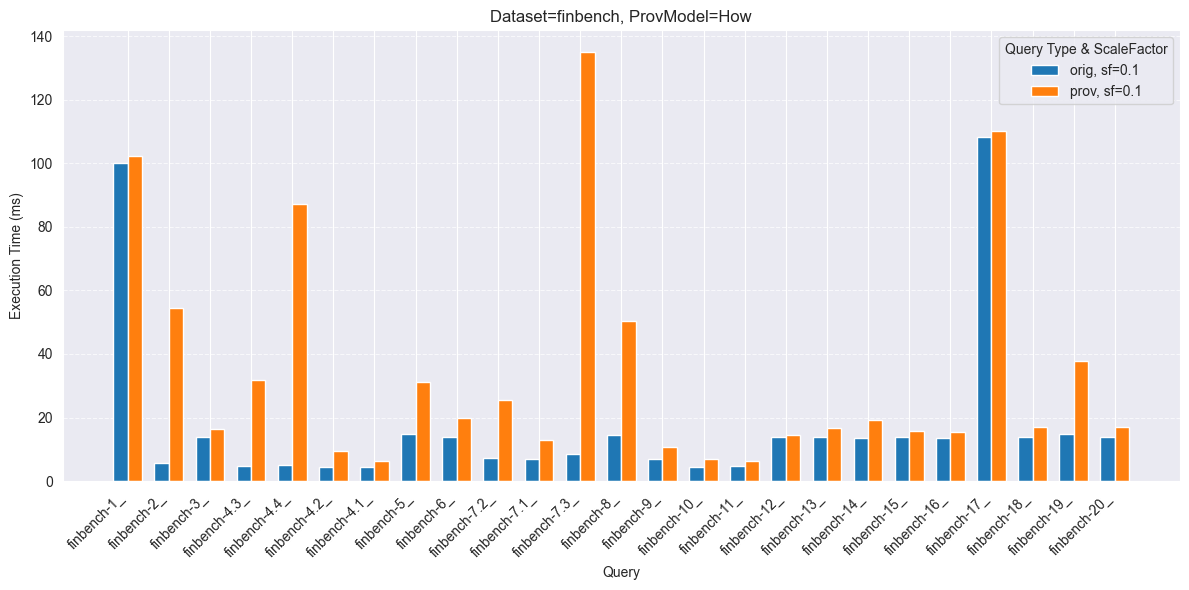

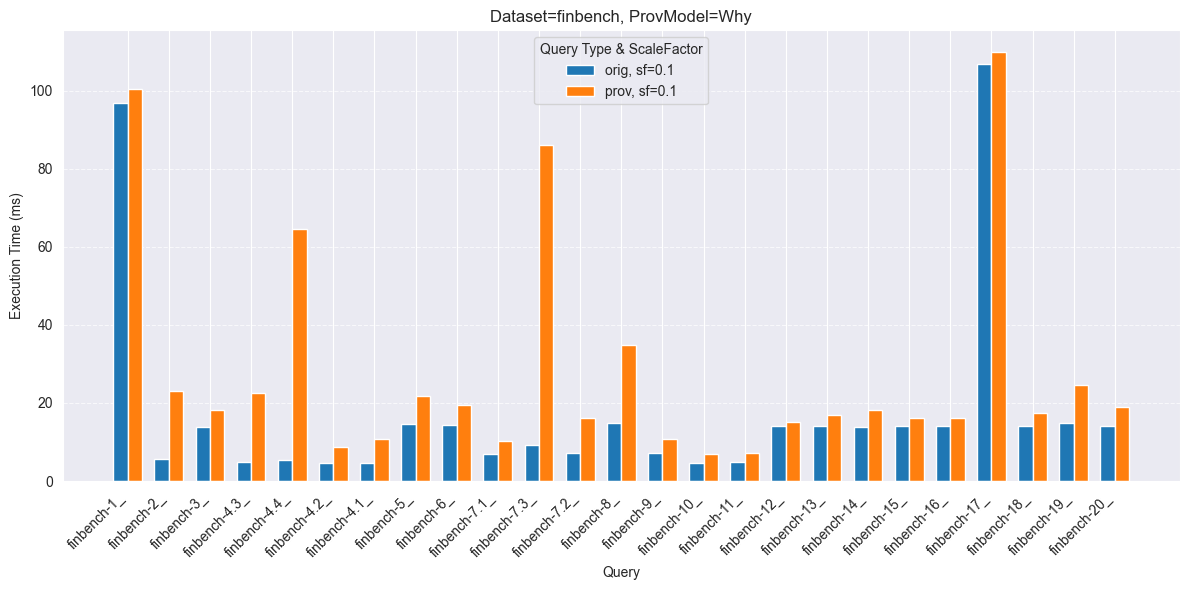

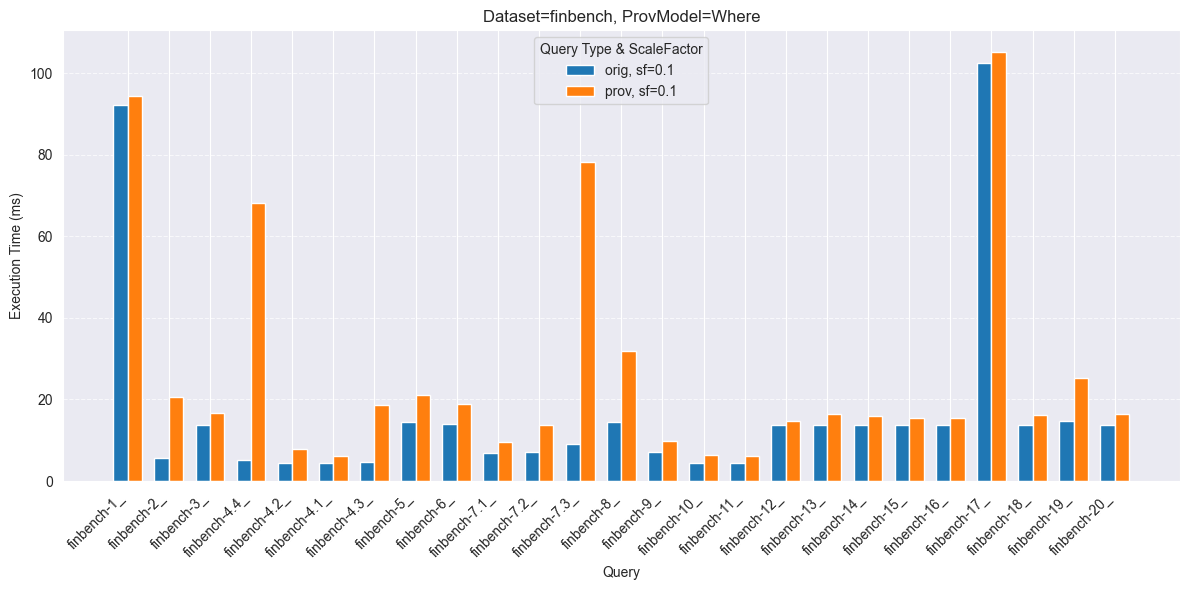

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# Load CSV
file_name = '2026-01-21_7-core-optimized_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")

# Extract base query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)
df = df[df["base_query"]!="finbench-7.4_"]

# Apply scaling
df["adjusted_mean"] = df["mean"] * 10
agg = (
    df.groupby(["dataset", "scaleFactor", "provModel", "base_query", "query_type"])
    .agg(total_mean=("adjusted_mean", "sum"))
    .reset_index()
)
agg["total_mean"] /= 100

# Sort by query number
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")

agg["query_num"] = agg["base_query"].apply(query_number)
agg = agg.sort_values("query_num")

datasets = agg["dataset"].unique()
prov_models = agg["provModel"].unique()
scale_factors = sorted(agg["scaleFactor"].unique())

for ds in datasets:
    for pm in prov_models:
        subset = agg[(agg["dataset"] == ds) & (agg["provModel"] == pm)]

        plt.figure(figsize=(12,6))

        x_labels = subset["base_query"].unique()
        x = np.arange(len(x_labels))
        n_sf = len(scale_factors)
        width = 0.35 / n_sf  # small enough for orig+prov per scaleFactor

        for i, sf in enumerate(scale_factors):
            sf_data = subset[subset["scaleFactor"] == sf].set_index("base_query").loc[x_labels]

            # Plot orig and prov side by side
            plt.bar(x - width/2 + i*width, sf_data[sf_data["query_type"]=="orig"]["total_mean"],
                    width=width, color="tab:blue", label=f"orig, sf={sf}" if i==0 else "")
            plt.bar(x + width/2 + i*width, sf_data[sf_data["query_type"]=="prov"]["total_mean"],
                    width=width, color="tab:orange", label=f"prov, sf={sf}" if i==0 else "")

        plt.xticks(x, x_labels, rotation=45, ha="right")
        plt.xlabel("Query")
        plt.ylabel("Execution Time (ms)")
        plt.title(f"Dataset={ds}, ProvModel={pm}")
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Remove duplicate legend entries
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), title="Query Type & ScaleFactor")

        plt.tight_layout()
        plt.show()


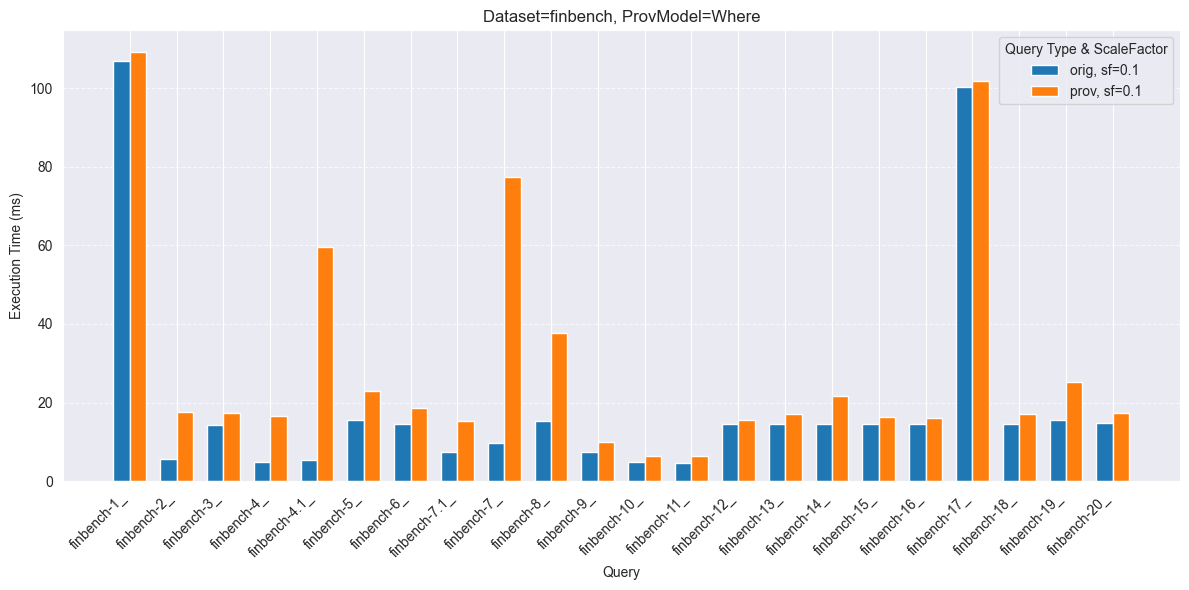

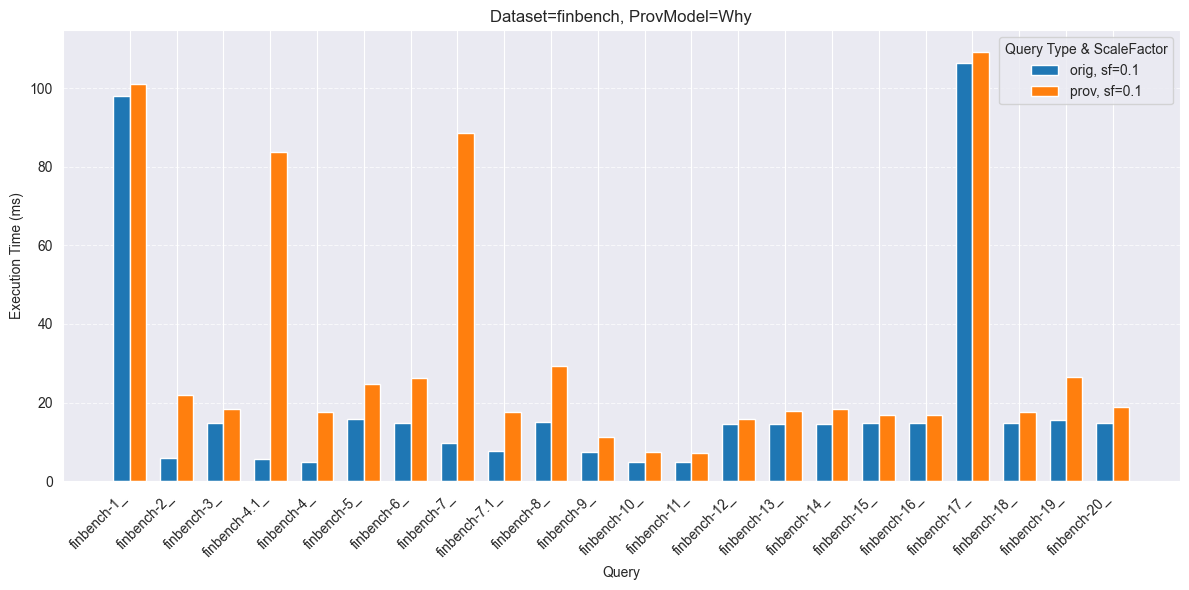

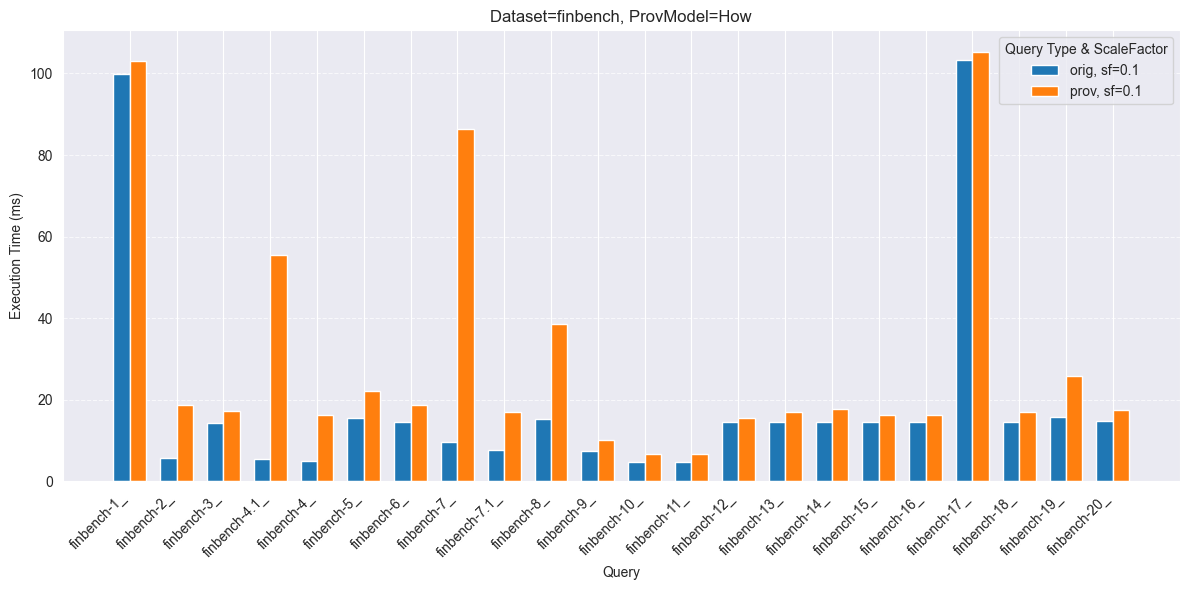

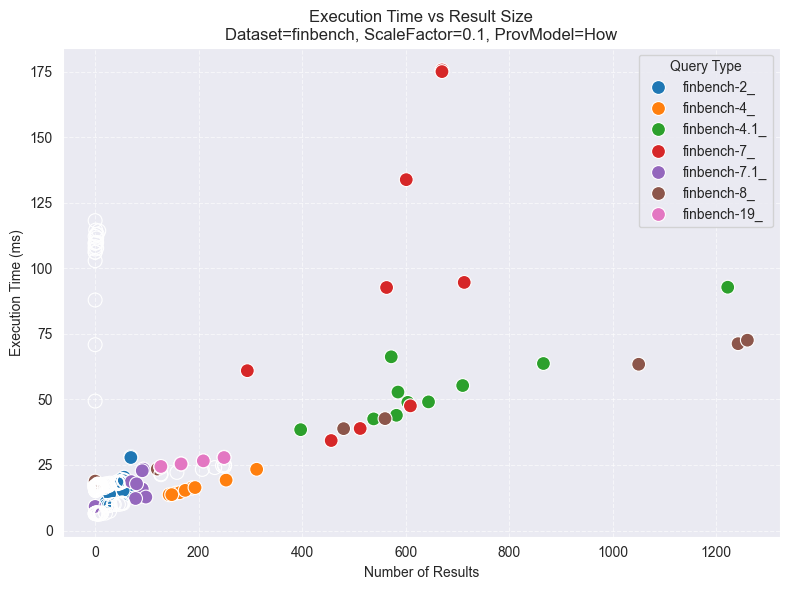

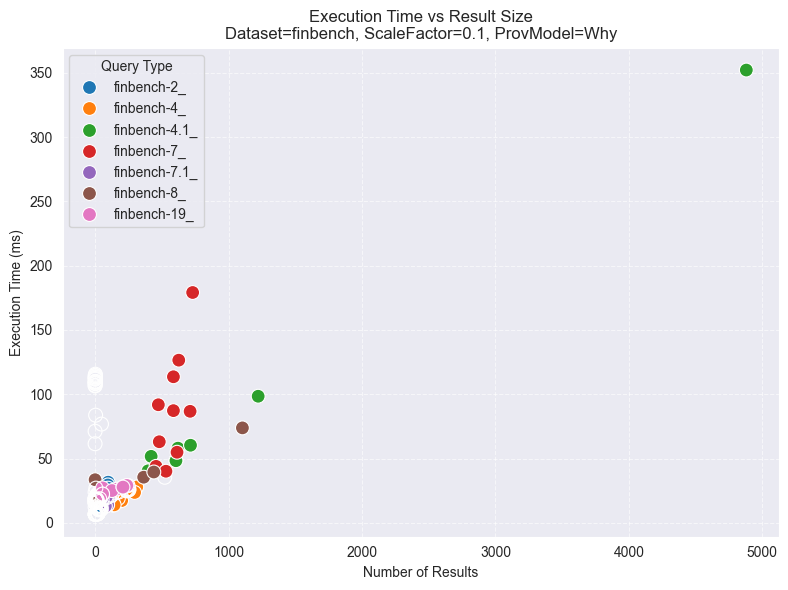

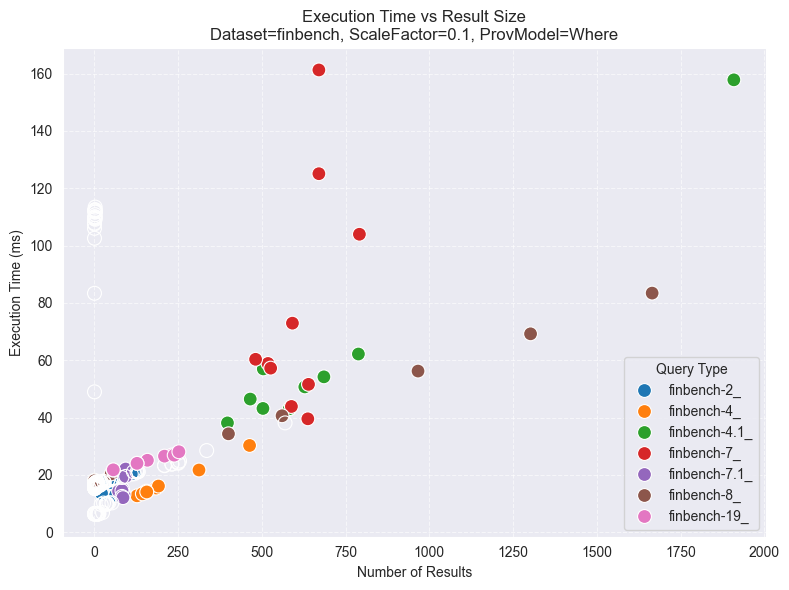

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import re
import numpy as np

# Load CSV
file_name = '2026-01-21_7-with-4n7-alt-1_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")
df= df[df["query_type"]=="prov"]

# Extract base query name
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

# df = df[df["base_query"].isin([
#                                 "finbench-2_",
#                                # "finbench-3_",
#                                "finbench-4_",
#                                "finbench-7_",
#                                "finbench-8_",
#                                "finbench-19_"
# ])]

df["adjusted_mean"] = df["mean"]  # or apply any scaling if needed
df["adjusted_results"] = df["resultSize"]

# agg = (
#     df.groupby(["dataset", "scaleFactor", "provModel", "base_query", "query_type"])
#     .agg(total_mean=("adjusted_mean", "sum"), total_results=("resultSize", "sum"))
#     .reset_index()
# )
#
# agg["total_mean"] /= 100
# agg["total_results"] /= 100

# Sort by query number
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")
# agg["query_num"] = agg["base_query"].apply(query_number)
# agg = agg.sort_values("query_num")
df["query_num"] = df["base_query"].apply(query_number)
df = df.sort_values("query_num")

# --- Scatter plot per provModel/dataset/scaleFactor ---
datasets = df["dataset"].unique()
scale_factors = df["scaleFactor"].unique()
prov_models = df["provModel"].unique()

for ds in datasets:
    for sf in scale_factors:
        for pm in prov_models:
            subset = df[
                (df["dataset"]==ds) &
                (df["scaleFactor"]==sf) &
                (df["provModel"]==pm)
                ]
            plt.figure(figsize=(8,6))
            sns.scatterplot(
                data=subset,
                x="adjusted_results",
                y="adjusted_mean",
                hue="base_query",
                hue_order=[
                    "finbench-2_",
                    # "finbench-3_",
                    "finbench-4_",
                    "finbench-4.1_",
                    "finbench-7_",
                    "finbench-7.1_",
                    "finbench-8_",
                    "finbench-19_"
                ],
                # ["orig", "prov"],
                s=100  # marker size
            )
            plt.title(f"Execution Time vs Result Size\nDataset={ds}, ScaleFactor={sf}, ProvModel={pm}")
            plt.xlabel("Number of Results")
            plt.ylabel("Execution Time (ms)")
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend(title="Query Type")
            plt.tight_layout()
            plt.show()


In [60]:
import pandas as pd
import re

# Assume df already has columns: query, resultSize, etc.
file_name = '2026-01-21_6_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))
# Extract base_query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

# Mark hits
df["hit"] = df["resultSize"] > 0

# Calculate hit rate per query (can also group by dataset/scaleFactor/provModel)
hitrate = (
    df.groupby(["dataset", "scaleFactor", "provModel", "base_query"])
    .agg(
        hits=("hit", "sum"),
        total=("hit", "count")
    )
    .reset_index()
)

# Add hit rate column
hitrate["hit_rate"] = hitrate["hits"] / hitrate["total"]

# Sort by query number extracted from base_query
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")

hitrate["query_num"] = hitrate["base_query"].apply(query_number)
hitrate = hitrate.sort_values(["provModel","query_num"])

# Keep only relevant columns
hitrate = hitrate[["dataset","scaleFactor","provModel","base_query","hit_rate"]]

print(hitrate)


     dataset  scaleFactor provModel    base_query  hit_rate
10  finbench          0.1       How   finbench-1_       0.1
12  finbench          0.1       How   finbench-2_       1.0
13  finbench          0.1       How   finbench-3_       0.0
14  finbench          0.1       How   finbench-4_       1.0
15  finbench          0.1       How   finbench-5_       1.0
16  finbench          0.1       How   finbench-6_       1.0
17  finbench          0.1       How   finbench-7_       1.0
18  finbench          0.1       How   finbench-8_       0.4
19  finbench          0.1       How   finbench-9_       1.0
0   finbench          0.1       How  finbench-10_       1.0
1   finbench          0.1       How  finbench-11_       0.6
2   finbench          0.1       How  finbench-12_       1.0
3   finbench          0.1       How  finbench-13_       0.8
4   finbench          0.1       How  finbench-14_       0.8
5   finbench          0.1       How  finbench-15_       1.0
6   finbench          0.1       How  fin